# `VP_pert` vs CLASS — direct comparison

Compares every output variable of `VP_pert` against CLASS at a fixed wavenumber.

**Variables compared** (all normalised to their $z=0$ value):
- Background: $E(z) = H(z)/H_0$
- Perturbations at $k = K_{\\rm comp}$: $\\delta_m$, $\\theta_m$, $\\phi$, and (for $w\\neq -1$) $\\delta_{\\rm DE}$, $\\theta_{\\rm DE}$

Each plot shows VP\_pert (solid) vs CLASS (dashed) with a percent residual panel below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from scipy.integrate import solve_ivp
from classy import Class

import sys, os
sys.path.insert(0, os.path.abspath('..'))
import VP_pert as vp

try:
    import scienceplots
    plt.style.use(['science', 'bright', 'vpedre'])
except ImportError:
    pass

H0_kms = 67.00
h      = H0_kms / 100
Om_b   = 0.049
Om_cdm = 0.27
Om_m   = Om_b + Om_cdm
Om_de  = 1.0 - Om_m

VP_BASE = {
    'H0 (km/s/Mpc)': H0_kms,
    'H0 (1/Mpc)'   : H0_kms / vp.c_kms,
    'h'            : h,
    'Omega_c0'     : Om_cdm,
    'Omega_b0'     : Om_b,
    'Omega_m0'     : Om_m,
    'cs2'          : 1.0,
}

DE_MODELS = {
    r'$\Lambda$CDM ($w=-1$)'   : (-1.0, 0.0),
    r'$w_0=-0.7$'               : (-0.7, 0.0),
    r'$w_0=-0.7,\,w_a=0.6$'   : (-0.7, 0.6),
    r'$w_0=-1.3,\,w_a=0.6$'   : (-1.3, 0.6),
}

COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']
print('Setup complete.')


Setup complete.


In [2]:
def run_class(w0=-1.0, wa=0.0):
    params = {
        'output'         : 'mPk, mTk',
        'gauge'          : 'newtonian',
        'h'              : h,
        'Omega_b'        : Om_b,
        'Omega_cdm'      : Om_cdm,
        'N_ncdm'         : 0,
        'N_ur'           : 3.046,
        'P_k_max_1/Mpc'  : 10.0,
        'z_max_pk'       : 500.0,
        'k_output_values': K_COMP,
    }
    if w0 == -1.0 and wa == 0.0:
        params['Omega_Lambda'] = Om_de
    else:
        params['Omega_fld'] = Om_de
        params['w0_fld']    = w0
        params['wa_fld']    = wa
        params['cs2_fld']   = 1.0
    cosmo = Class()
    cosmo.set(params)
    cosmo.compute()
    return cosmo


def run_vp(w0=-1.0, wa=0.0, k=None, a_ini=1e-4):
    k = k or K_COMP
    p = dict(VP_BASE)
    p['w0'] = w0
    p['wa']  = wa
    phi_ini     = -1e-9
    H_ini       = vp.Hubble(a_ini, p)
    H_conf      = a_ini * H_ini
    delta_m_ini = -2.0 * phi_ini * (1.0 + k**2 / (3.0 * H_conf**2))
    vm_ini      =  2.0 * k**2 * phi_ini / (3.0 * H_conf)
    sol = solve_ivp(
        vp.rhs_pert, (a_ini, 1.0), [delta_m_ini, vm_ini, 0.0, 0.0, phi_ini],
        args=(k, p), method='RK45', dense_output=True, rtol=1e-9, atol=1e-12,
    )
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol, p


K_COMP = 1e-3   # comparison wavenumber [Mpc^-1]


In [3]:
class_cosmos = {lbl: run_class(w0, wa) for lbl, (w0, wa) in DE_MODELS.items()}
vp_sols      = {lbl: run_vp(w0, wa)[0]  for lbl, (w0, wa) in DE_MODELS.items()}
print('All solutions ready.')


All solutions ready.


In [4]:
class_cosmos['$w_0=-0.7,\\,w_a=0.6$'].get_perturbations()['scalar'][0].keys()

dict_keys(['tau [Mpc]', 'a', 'delta_g', 'theta_g', 'shear_g', 'pol0_g', 'pol1_g', 'pol2_g', 'delta_b', 'theta_b', 'psi', 'phi', 'delta_ur', 'theta_ur', 'shear_ur', 'delta_cdm', 'theta_cdm', 'delta_rho_fld', 'rho_plus_p_theta_fld', 'delta_p_fld'])

## 1 — Background: $E(z) = H(z)/H_0$

The radiation contribution present in CLASS but absent in `VP_pert` causes a systematic offset that grows with $z$.

/var/folders/5s/qjyr0m0s7md6xl0nnsqwt72h0000gn/T/ipykernel_9145/922567123.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


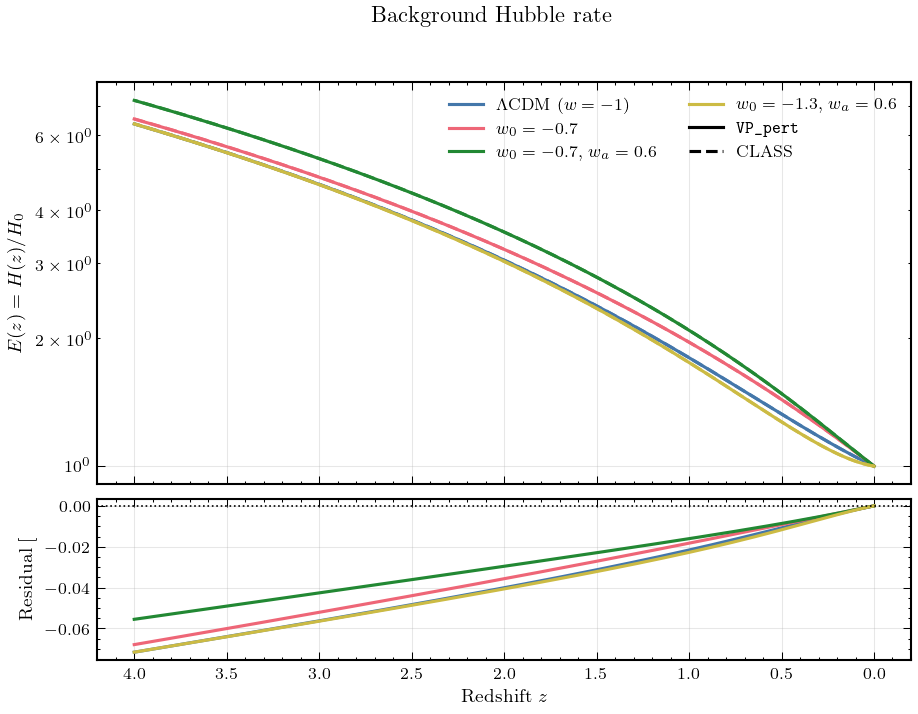

In [5]:
z_bg = np.linspace(0, 4, 300)
a_bg = 1.0 / (1.0 + z_bg)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.05})

for i, (label, (w0, wa)) in enumerate(DE_MODELS.items()):
    p = dict(VP_BASE); p['w0'] = w0; p['wa'] = wa
    E_vp = vp.EHubble(a_bg, pars=p)
    E_cl = np.array([class_cosmos[label].Hubble(z) / class_cosmos[label].Hubble(0)
                     for z in z_bg])
    ax1.semilogy(z_bg, E_vp, color=COLORS[i], label=label)
    ax1.semilogy(z_bg, E_cl, color=COLORS[i], ls='--')
    ax2.plot(z_bg, 100*(E_vp/E_cl - 1), color=COLORS[i])

proxy = [Line2D([0],[0], color='k', lw=1.5,        label=r'\texttt{VP\_pert}'),
         Line2D([0],[0], color='k', lw=1.5, ls='--', label='CLASS')]
handles, _ = ax1.get_legend_handles_labels()
ax1.legend(handles=handles+proxy, fontsize=8, ncol=2)
ax1.set_ylabel(r'$E(z) = H(z)/H_0$')
ax2.axhline(0, color='k', lw=0.8, ls=':')
ax2.set_xlabel(r'Redshift $z$')
ax2.set_ylabel('Residual [%]')
ax2.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax1.invert_xaxis()
fig.suptitle('Background Hubble rate')
fig.tight_layout()
plt.savefig('figs/hubble_comparison.pdf', bbox_inches='tight')
plt.show()


## 2 — Perturbations at $k = K_{\rm comp}$

All variables are normalised to their $z=0$ value. For $\Lambda$CDM there are no DE fluid perturbations, so only $\delta_m$, $\theta_m$, $\phi$ are shown. Non-$\Lambda$CDM models additionally show $\delta_{\rm DE}$ and $\theta_{\rm DE}$.

In [7]:
for i, (label, (w0, wa)) in enumerate(DE_MODELS.items()):
    sol  = vp_sols[label]
    pert = class_cosmos[label].get_perturbations()['scalar'][0]
    bk = class_cosmos[label].get_background()
    # CLASS native time grid filtered to 0 <= z <= 100
    a_cl = pert['a']
    mask = a_cl >= 1.0/101.0
    a_cl = a_cl[mask]
    z_cl = 1.0/a_cl - 1.0   # decreasing: high-z left, z=0 right

    avail = [k for k in pert if k not in ('a', 'tau')]
    print(f'{label}  ->  {avail}')

    # CLASS matter
    dm_cl = (Om_b*pert['delta_b'][mask] + Om_cdm*pert['delta_cdm'][mask]) / Om_m
    tm_cl = (Om_b*pert['theta_b'][mask] + Om_cdm*pert['theta_cdm'][mask]) / Om_m
    ph_cl = pert['phi'][mask]
    dm_cl /= dm_cl[-1];  tm_cl /= tm_cl[-1];  ph_cl /= ph_cl[-1]

    # VP_pert on the same a grid; normalise to a=1 (z=0)
    norm = lambda idx: sol.sol([1.0])[idx][0]
    dm_vp = np.array([sol.sol([a])[0][0] for a in a_cl]) / norm(0)
    vm_vp = np.array([sol.sol([a])[1][0] for a in a_cl]) / norm(1)
    ph_vp = np.array([sol.sol([a])[4][0] for a in a_cl]) / norm(4)

    quants = [
        (dm_vp, dm_cl, r'$\delta_m/\delta_m(0)$'),
        (vm_vp, tm_cl, r'$\theta_m/\theta_m(0)$'),
        (ph_vp, ph_cl, r'$\phi/\phi(0)$'),
    ]

    if 'delta_rho_fld' in pert:
        rho_fld = bk['(.)rho_fld'][mask]

        # delta_DE = delta_rho_fld / rho_fld
        dde_cl = pert['delta_rho_fld'][mask] / rho_fld
        dde_cl /= dde_cl[-1]

        # theta_DE = rho_plus_p_theta_fld / (rho_fld * (1 + w(a)))
        # w(a) = w0 + wa*(1-a);  mask denominator near zero (phantom crossing)
        w_a   = w0 + wa * (1.0 - a_cl)
        denom = rho_fld * (1.0 + w_a)
        safe  = np.abs(denom) > 1e-6 * np.max(np.abs(denom))
        tde_cl = np.where(safe, pert['rho_plus_p_theta_fld'][mask] / np.where(safe, denom, 1.0), np.nan)
        tde_cl /= np.nanmax(np.abs(tde_cl[-10:]))   # normalise near z=0

        dde_vp = np.array([sol.sol([a])[2][0] for a in a_cl]) / norm(2)
        vde_vp = np.array([sol.sol([a])[3][0] for a in a_cl]) / norm(3)

        quants += [
            (dde_vp, dde_cl, r'$\delta_{\rm DE}/\delta_{\rm DE}(0)$'),
            (vde_vp, tde_cl, r'$\theta_{\rm DE}/\theta_{\rm DE}(0)$'),
        ]

    ncols = len(quants)
    fig, axes = plt.subplots(2, ncols, figsize=(4.5*ncols, 5.5), sharex=True,
                              gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.05})

    for j, (vp_arr, cl_arr, ylabel) in enumerate(quants):
        axes[0, j].plot(z_cl, vp_arr, color=COLORS[0], label=r'\texttt{VP\_pert}')
        axes[0, j].plot(z_cl, cl_arr, color=COLORS[1], ls='--', label='CLASS')
        axes[0, j].set_ylabel(ylabel)
        if j == 0:
            axes[0, j].legend()

        axes[1, j].plot(z_cl, 100*(vp_arr/cl_arr - 1), color=COLORS[2])
        axes[1, j].axhline(0, color='k', lw=0.8, ls=':')
        axes[1, j].set_xlabel(r'Redshift $z$')
        axes[1, j].set_ylabel('Residual [%]')
        axes[1, j].yaxis.set_minor_locator(mticker.AutoMinorLocator())

    fig.suptitle(label + f', $k = {K_COMP:.0e}' + r'\,{\rm Mpc}^{-1}$', y=1.01)
    fig.tight_layout()
    plt.savefig(f'figs/comparison_{i+1:02d}.pdf', bbox_inches='tight')
    plt.show()


$\Lambda$CDM ($w=-1$)  ->  ['tau [Mpc]', 'delta_g', 'theta_g', 'shear_g', 'pol0_g', 'pol1_g', 'pol2_g', 'delta_b', 'theta_b', 'psi', 'phi', 'delta_ur', 'theta_ur', 'shear_ur', 'delta_cdm', 'theta_cdm', 'delta_rho_fld', 'rho_plus_p_theta_fld', 'delta_p_fld']


IndexError: boolean index did not match indexed array along axis 0; size of axis is 40000 but size of corresponding boolean axis is 531

In [ ]:
for c in class_cosmos.values():
    c.struct_cleanup()
print('Done.')


Done.
